# End-to-end evaluation: fixed timer vs stateAI

> **All data in this notebook is simulated.** The result shows that the integrated system works end to
> end (sensing, windows, rules, smoothing, haptic policy, rate limits and pauses) inside a simulated
> world. It does **not** show that stateAI is better than a fixed timer for real people.

**What is simulated.** The five synthetic users of `stateai_ml.synthetic` (rhythms of 60, 90 and 110
minutes, one without rhythm and one irregular) each live the same 14 days twice: once with a fixed
25/5 timer and once with stateAI. A day is four 90-minute work periods. The person is a closed-loop
version of the synthetic user (`stateai_ml/endtoend/world.py`): a latent state (calm / engaged /
strained) drives heart rate and movement; effort builds up with work (faster when strained) and pauses
recover it.

**Why this is not circular, and where it still is.** stateAI never sees the latent state: it sees
only the noisy signal and estimates the level with the watch's rules, which work differently from the
generator. But the *recovery rules* of the world (how much a pause helps, what breaking calm focus
costs) are modeling choices, and they decide how much a well-timed pause pays off. Change them and the
comparison changes.

**Metrics** come from the ground-truth latent state during work: minutes in focus (`LOW`), minutes in
overload (`HIGH`), minutes restless, and pauses taken.

Run from `ml-python` after `pip install -r requirements-notebook.txt`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from stateai_ml.endtoend.day import plan_day
from stateai_ml.endtoend.metrics import summarize
from stateai_ml.endtoend.policy import FixedTimer
from stateai_ml.endtoend.runner import POLICIES, run
from stateai_ml.endtoend.simulation import simulate_day
from stateai_ml.endtoend.stateai_policy import StateAIPolicy
from stateai_ml.synthetic.users import USERS

DAYS = 14
USER_SPECS = list(USERS.values())
COLORS = {"fixed_timer": "#2a78d6", "stateai": "#eb6834", "fixed_timer_50": "#1baf7a"}
LABELS = {"fixed_timer": "Fixed timer 25/5", "stateai": "stateAI", "fixed_timer_50": "Fixed timer 50/5"}
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e4e3df"

plt.rcParams.update(
    {
        "figure.dpi": 110,
        "font.size": 10,
        "axes.edgecolor": GRID,
        "axes.labelcolor": MUTED,
        "axes.titlecolor": INK,
        "axes.titlesize": 11,
        "axes.titleweight": "bold",
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "axes.grid": True,
        "grid.color": GRID,
        "grid.linewidth": 0.6,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "legend.frameon": False,
    }
)

## 1. The mean day

The fixed 50/5 timer is added as a reference: it pauses about as little as stateAI, so it separates
the effect of *how many* pauses from the effect of *when* they happen.

In [2]:
policies = POLICIES | {"fixed_timer_50": lambda start: FixedTimer(work_minutes=50)}
per_day = run(USER_SPECS, DAYS, policies)
summary = summarize(per_day).loc[list(LABELS)]
summary.rename(index=LABELS)

,work_minutes,focus_minutes,overload_minutes,restless_minutes,pauses,pause_minutes,focus_share,overload_share
policy,,,,,,,,
Fixed timer 25/5,300.000,138.529,48.129,0.000,12.0,60.000,0.462,0.160
stateAI,325.557,144.000,49.200,10.014,7.0,34.443,0.442,0.151
Fixed timer 50/5,340.000,137.486,66.586,8.586,4.0,20.000,0.404,0.196


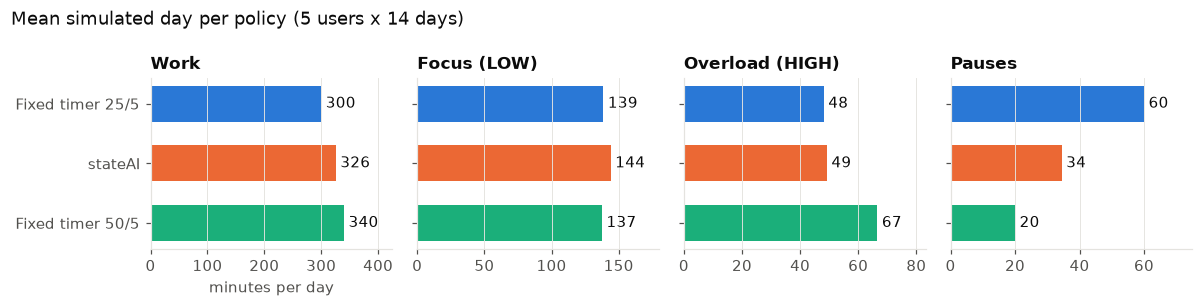

In [3]:
metrics = ["work_minutes", "focus_minutes", "overload_minutes", "pause_minutes"]
titles = ["Work", "Focus (LOW)", "Overload (HIGH)", "Pauses"]
fig, axes = plt.subplots(1, 4, figsize=(11, 2.8), sharey=True)
for ax, metric, title in zip(axes, metrics, titles, strict=True):
    values = summary[metric]
    bars = ax.barh([LABELS[p] for p in values.index], values, color=[COLORS[p] for p in values.index], height=0.6)
    ax.bar_label(bars, fmt="%.0f", padding=3, color=INK)
    ax.set_title(title, loc="left")
    ax.set_xlim(0, values.max() * 1.25)
    ax.grid(axis="y", visible=False)
axes[0].invert_yaxis()
axes[0].set_xlabel("minutes per day")
fig.suptitle("Mean simulated day per policy (5 users x 14 days)", x=0.01, ha="left", color=INK)
fig.tight_layout()

## 2. Day by day, per user

Paired differences (stateAI minus the 25/5 timer) on the same simulated day. Each dot is one day; the
black bar is the mean per user.

,focus_minutes,overload_minutes
user,,
cycle110,11.3,1.4
cycle60,1.8,-2.4
cycle90,8.4,-2.6
irregular,8.3,-4.9
no_cycle,-2.4,13.8


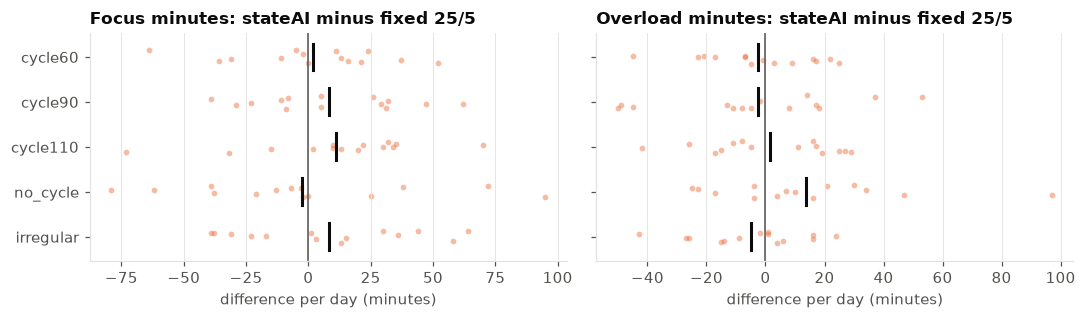

In [4]:
wide = per_day.pivot_table(index=["user", "day"], columns="policy", values=["focus_minutes", "overload_minutes"])
diff = wide.xs("stateai", axis=1, level=1) - wide.xs("fixed_timer", axis=1, level=1)
users = list(USERS)
fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharey=True)
rng = np.random.default_rng(0)
diff_titles = {"focus_minutes": "Focus minutes", "overload_minutes": "Overload minutes"}
for ax, (metric, title) in zip(axes, diff_titles.items(), strict=True):
    for row, user in enumerate(users):
        values = diff.loc[user, metric]
        jitter = row + rng.uniform(-0.15, 0.15, len(values))
        ax.scatter(values, jitter, s=14, color=COLORS["stateai"], alpha=0.45, linewidths=0)
        ax.plot([values.mean()] * 2, [row - 0.3, row + 0.3], color=INK, linewidth=2)
    ax.axvline(0, color=MUTED, linewidth=1)
    ax.set_yticks(range(len(users)), users)
    ax.set_title(f"{title}: stateAI minus fixed 25/5", loc="left")
    ax.set_xlabel("difference per day (minutes)")
    ax.grid(axis="y", visible=False)
axes[0].invert_yaxis()
fig.tight_layout()
diff.groupby("user").mean().round(1)

## 3. One day, minute by minute

The same day of the `cycle90` user with both policies. The line is the ground-truth latent level;
gray bands are pauses.

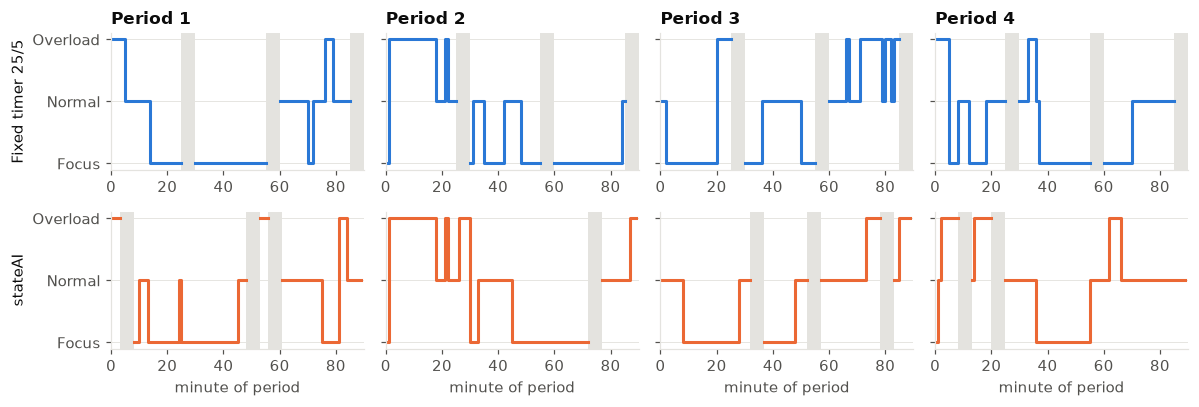

In [5]:
plan = plan_day(USERS["cycle90"], 3)
days = {
    "fixed_timer": simulate_day(plan, POLICIES["fixed_timer"]),
    "stateai": simulate_day(plan, POLICIES["stateai"]),
}
level_value = {"LOW": 0, "MEDIUM": 1, "HIGH": 2}
fig, axes = plt.subplots(2, 4, figsize=(11, 3.8), sharey=True)
for row, (policy, minutes) in enumerate(days.items()):
    for col, (period, block) in enumerate(minutes.groupby("period")):
        ax = axes[row, col]
        x = (block["minute_of_day"] - block["minute_of_day"].iloc[0]).to_numpy()
        y = block["level"].map(level_value).to_numpy(dtype=float)
        ax.step(x, y, where="post", color=COLORS[policy], linewidth=2)
        pause = block["activity"].eq("pause").to_numpy()
        for start in x[pause & ~np.roll(pause, 1)]:
            ax.axvspan(start, start + 5, color=GRID, linewidth=0)
        ax.set_yticks([0, 1, 2], ["Focus", "Normal", "Overload"])
        ax.set_xlim(0, 90)
        ax.grid(axis="x", visible=False)
        if row == 0:
            ax.set_title(f"Period {period + 1}", loc="left")
        else:
            ax.set_xlabel("minute of period")
    axes[row, 0].set_ylabel(LABELS[policy], color=INK)
fig.tight_layout()

## 4. How much it depends on the person following cues

stateAI only suggests. The simulated person follows a played cue with probability `compliance`
(0.8 in the main run).

,work_minutes,focus_minutes,overload_minutes,restless_minutes,pauses
0.00,360.0,128.9,87.1,84.1,0.0
0.25,347.0,134.3,73.4,49.6,2.6
0.50,336.8,141.4,61.2,26.0,4.7
0.80,325.6,144.0,49.2,10.0,7.0
1.00,320.1,145.7,42.1,4.4,8.2


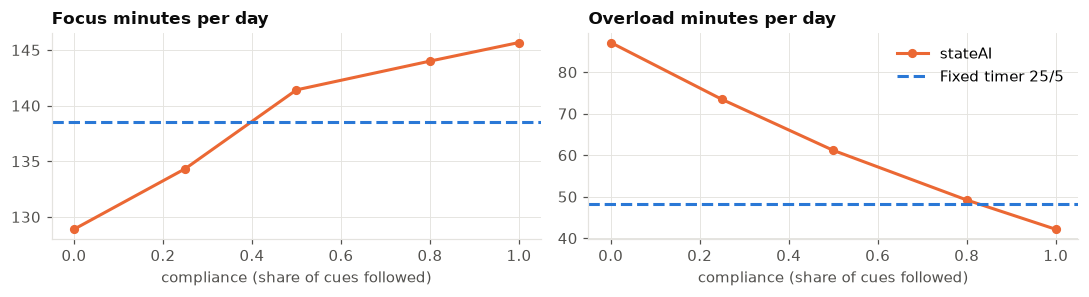

In [6]:
rows = []
for compliance in [0.0, 0.25, 0.5, 0.8, 1.0]:
    factory = {
        "stateai": lambda start, c=compliance: StateAIPolicy(start.resting_heart_rate, start.seed, compliance=c),
    }
    rows.append(summarize(run(USER_SPECS, DAYS, factory)).iloc[0].rename(compliance))
sweep = pd.DataFrame(rows)
fig, axes = plt.subplots(1, 2, figsize=(10, 2.8))
sweep_titles = {"focus_minutes": "Focus minutes per day", "overload_minutes": "Overload minutes per day"}
for ax, (metric, title) in zip(axes, sweep_titles.items(), strict=True):
    ax.plot(sweep.index, sweep[metric], color=COLORS["stateai"], linewidth=2, marker="o", markersize=5, label="stateAI")
    timer = summary.loc["fixed_timer", metric]
    ax.axhline(timer, color=COLORS["fixed_timer"], linewidth=2, linestyle="--", label="Fixed timer 25/5")
    ax.set_title(title, loc="left")
    ax.set_xlabel("compliance (share of cues followed)")
axes[1].legend(loc="upper right")
fig.tight_layout()
sweep[["work_minutes", "focus_minutes", "overload_minutes", "restless_minutes", "pauses"]].round(1)

## Reading the results

In this simulated world, with the default settings:

- **stateAI works about 26 minutes more per day than the 25/5 timer** (326 vs 300) because it pauses
  less (7 vs 12 pauses a day), and spends about the same minutes in overload (49 vs 48) and a few more
  in focus (144 vs 139). As a *share* of work time, focus is slightly lower (44 % vs 46 %) and
  overload slightly lower (15 % vs 16 %).
- **When the pauses happen matters.** The 50/5 timer pauses about as little as stateAI and works a
  similar amount, but spends far more time in overload (20 % of work vs 15 %). stateAI pauses when the
  signal shows sustained load, restlessness or the end of a block, and in this world that is when a
  pause helps most.
- **The effect is small and varies by user and day.** stateAI has more focus minutes than the 25/5
  timer on about half of the days, and the user without a rhythm (`no_cycle`) ends up with more
  overload.
- **It only works if the person follows the cues.** stateAI has more focus than the 25/5 timer only
  when about 40 % or more of the cues are followed, and matches its overload only at about 80 %.
  Ignoring every cue (compliance 0) means working until each period ends: 87 overload minutes a day.
- **Restlessness appears with stateAI** (about 10 minutes a day) and not with the 25/5 timer, because
  longer blocks reach the late, fatigued part of a session where the world makes restlessness likely.

**What this does and does not show.** It shows that the whole pipeline runs end to end on realistic
signals, that its cues fire on sustained states, and that the rate limits and the "suggest, never
force" design behave as intended. It does **not** show that stateAI beats a fixed timer for people:
the world's recovery rules are our choice, the users are synthetic, and a different but equally
plausible world could reverse the comparison. That needs a study with real people, which is out of
scope (`docs/SPEC.md`, section 8).